In [2]:
%pip install "numpy<2" cvxeda

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install "scikit-learn>=1.4.2" "numpy>=2.0" "scipy>=1.10"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 45.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 33.1 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.2.0
    Uninstalling threadpoolctl-3.2.0:
      Successfully uninstalled threadpoolctl-3.2.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.3.2
    Uninstalling joblib-1.3.2:
      Successfully uninstalled joblib-1.3.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.0
    Uninstalling scikit-learn-1.3.0:
      Successfully uninstalled scikit-learn-1.3.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import os
import neurokit2 as nk
import cvxeda as cvxEDA
import scipy.stats as stats
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import plotly.express as px
import plotly.figure_factory as ff
from sklearn.preprocessing import MinMaxScaler
import warnings
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')
os.chdir('/notebooks/EEVR')

sampling_freq = 15.625

In [6]:
raw_eda = pd.read_csv("Data_files/Raw_EDA.csv")
raw_eda

,Time,EDA,Label,Participant ID,Gender,Playlist ID,Video ID,CMA,VideoName,Video_ID_number
0,0.000000,2.855,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
1,0.002133,2.859,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
2,0.004267,2.867,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
3,0.006400,2.879,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
4,0.008533,2.895,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
...,...,...,...,...,...,...,...,...,...,...
429915,23.840000,10.290,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8
429916,23.840000,10.300,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8
429917,23.840000,10.320,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8
429918,23.840000,10.340,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8


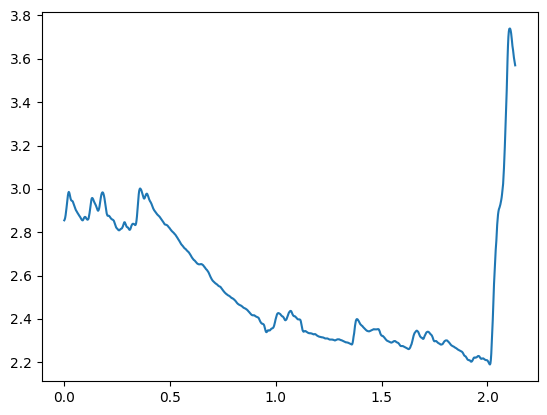

In [12]:
final_df = raw_eda[raw_eda['CMA'].isin(['HVLA', 'LVLA', 'LVHA', 'HVHA', 'Baseline'])] 
# kept only those rows where they clearly got the category, if signal was tempered and categorization
# was not defined those rows are exluded. 
plt.plot(final_df['Time'][:1000],final_df['EDA'][:1000])

In [8]:
final_df

,Time,EDA,Label,Participant ID,Gender,Playlist ID,Video ID,CMA,VideoName,Video_ID_number
0,0.000000,2.855,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
1,0.002133,2.859,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
2,0.004267,2.867,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
3,0.006400,2.879,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
4,0.008533,2.895,0_Baseline_Baseline,12,Male,1,0,Baseline,Baseline,0
...,...,...,...,...,...,...,...,...,...,...
429915,23.840000,10.290,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8
429916,23.840000,10.300,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8
429917,23.840000,10.320,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8
429918,23.840000,10.340,V8_HVHA_Mega Coaster,5,Female,4,V8,HVHA,Mega Coaster,8


In [13]:
final_df['Video_ID_number'] = [int(part.split('V')[-1]) for part in final_df['Video ID']]
final_df['Video_ID_number']
#final_df.to_csv("../Data_files/Stimuli_EDA.csv", index=False)

OSError: Cannot save file into a non-existent directory: '../Data_files'

In [ ]:
final_df

In [24]:
def label_prep(merged_df):
    vads = pd.read_csv("Data_files/VADS.csv") #getting label csv
    print("reading vad")
    # VADS = Valence, Arousal, Dominance, Significance

    #adding arousal, valence and dominance columns to orginal data csv
    for index, row in tqdm(merged_df.iterrows()):
        matching_rows = vads[(vads['Participant ID'] == row['Participant ID']) & (vads['Video ID'] == row['Video_ID_number'])]

        if not matching_rows.empty:

            merged_df.at[index, 'Valence'] = matching_rows['Valence'].iloc[0]
            merged_df.at[index, 'Arousal'] = matching_rows['Arousal'].iloc[0]
            merged_df.at[index, 'Dominance'] = matching_rows['Dominance'].iloc[0]
            merged_df.at[index, 'significance'] = matching_rows['significance'].iloc[0]

    print("binning...")
    # Define the bins and labels for categorization
    bins = [1, 3, 5]  # Define the bin edges
    labels = [0, 1]   # Define the corresponding labels (0 (Low) for 1-3:, 1 (High) for 4-5)

    # Use the cut function to categorize the 'arousal' column
    merged_df['arousal_category'] = pd.cut(merged_df['Arousal'], bins=bins, labels=labels, include_lowest=True)
    merged_df['valence_category'] = pd.cut(merged_df['Valence'], bins=bins, labels=labels, include_lowest=True)

    # Convert the 'category' column to integer type if needed
    merged_df['arousal_category'] = merged_df['arousal_category'].astype(int)
    merged_df['valence_category'] = merged_df['valence_category'].astype(int)

    print("mapping")
    mapping = {
    'Baseline': 0,
    'LVLA': 0,
    'LVHA': 0,
    'HVHA': 1,
    'HVLA': 1  # Baseline and HVLA mapped to 0 HV =1, LV = 0
    }

    # Apply the mapping to the 'CMA' column
    merged_df['taskwiselabel'] = merged_df['CMA'].map(mapping)
    # autofet_df

    three_class_mapping = {
    'Baseline': 1,
    'LVLA': 1,
    'LVHA': 0,
    'HVHA': 1,
    'HVLA': 2  
    }

    merged_df['three_class_label'] = merged_df['CMA'].map(three_class_mapping)
    return merged_df

# eda_data_with_labels = label_prep(final_df)
# eda_data_with_labels.to_csv("EDA_data_with_labels.csv")

Statistical features

In [15]:
# cvxEDA
def eda_stats(y):
    Fs = 15.625
    yn = (y - y.mean()) / y.std()
    [r, p, t, l, d, e, obj] = cvxEDA.cvxEDA(yn, 1. / Fs)
    return [r, p, t, l, d, e, obj]

def shannon_entropy(window):
    p = np.abs(window) / np.sum(np.abs(window))
    return -np.sum(p * np.log2(p + 1e-10))

def first_derivative(signal):
    if len(signal) > 1:
        time_values = np.arange(len(signal))
        first_derivative = np.gradient(signal, time_values)
        return first_derivative
    else:
        return np.array([])


def second_derivative(signal):
    fd = first_derivative(signal)
    time_values = np.arange(len(fd))
    second_derivative = np.gradient(first_derivative)
    return second_derivative


def calculate_integral(window):
    a = np.sum(np.abs(window))
    return a

def calculate_avg_power(window):
    avg_power = np.mean(np.square(np.abs(window)))
    return avg_power

def calculate_arc_length(window):
    diff_signal = np.diff(window)
    arc_length = np.sum(np.sqrt(1 + np.square(diff_signal)))
    return arc_length

def slope(window):
    if len(window) > 1:
        time_values = np.arange(len(window))
        slope, _ = np.polyfit(time_values, window, 1)
        return slope
    else:
        return np.nan

segments - participant-video

In [18]:
df_list = {}
for pi in final_df['Participant ID'].unique():
    df_pi = final_df[final_df['Participant ID'] == pi]
    for vi in final_df['Video ID'].unique():
        # print(pi,vi)
        df_vi =  df_pi[df_pi['Video ID'] == vi]
        tag = str(pi) + '_' + vi
        df_list[tag] = (df_vi)
df_list

{'12_0':           Time    EDA                Label  Participant ID Gender  \
 0     0.000000  2.855  0_Baseline_Baseline              12   Male   
 1     0.002133  2.859  0_Baseline_Baseline              12   Male   
 2     0.004267  2.867  0_Baseline_Baseline              12   Male   
 3     0.006400  2.879  0_Baseline_Baseline              12   Male   
 4     0.008533  2.895  0_Baseline_Baseline              12   Male   
 ...        ...    ...                  ...             ...    ...   
 1446  3.085000  3.583  0_Baseline_Baseline              12   Male   
 1447  3.087000  3.576  0_Baseline_Baseline              12   Male   
 1448  3.089000  3.598  0_Baseline_Baseline              12   Male   
 1449  3.091000  3.662  0_Baseline_Baseline              12   Male   
 1450  3.093000  3.764  0_Baseline_Baseline              12   Male   
 
       Playlist ID Video ID       CMA VideoName  Video_ID_number  
 0               1        0  Baseline  Baseline                0  
 1              

In [19]:
df_list['10_V1']

,Time,EDA,Label,Participant ID,Gender,Playlist ID,Video ID,CMA,VideoName,Video_ID_number
118018,3.089,6.092,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
118019,3.091,6.401,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
118020,3.093,6.615,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
118021,3.095,6.708,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
118022,3.098,6.704,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
...,...,...,...,...,...,...,...,...,...,...
118662,4.463,7.087,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
118663,4.465,7.089,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
118664,4.467,7.089,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1
118665,4.469,7.085,V1_LVHA_War Knows No Nation,10,Male,3,V1,LVHA,War Knows No Nation,1


In [20]:
sampling_freq = 15.625 #15.625 samples per second (Hz). original freq is set at 2000 Hz
out_df = pd.DataFrame()

for i in df_list:

    row_dict = {}

    pid = df_list[i]['Participant ID'].tolist()[0]
    vid = df_list[i]['Video ID'].tolist()[0]
    gender = df_list[i]['Gender'].tolist()[0]
    cma = df_list[i]['CMA'].tolist()[0]
    vnum = df_list[i]['Video_ID_number'].tolist()[0]

    eda_data = df_list[i]['EDA'].to_numpy()


    eda_clean = nk.eda_clean(eda_data, sampling_rate=sampling_freq ,method='biosppy') #Cleaning eda signal using NK
    x = np.array(eda_clean)
    # r, p, t, l, d, e, obj = eda_stats(eda_clean) #cvxeda for seperating phasic and tonic
    # scr = r 
    # scl = t 
    eda = nk.eda_phasic(x, sampling_freq)
    scr = np.array(eda['EDA_Phasic'])
    scl = np.array(eda['EDA_Tonic'])

    x_axis = np.linspace(0, scl.shape[0]/sampling_freq, scl.shape[0])
    
    #raw eda features
    row_dict['mean'] = np.mean(x) # Mean
    row_dict['std'] = np.std(x) # Standard Deviation
    row_dict['min'] = np.min(x) # Minimum
    row_dict['max'] = np.max(x) # Maximum
    row_dict['median_eda'] = np.quantile(x,0.5) #median
    row_dict['ku_eda'] = stats.kurtosis(x) #kurtosis
    row_dict['sk_eda'] = stats.skew(x) #skewness
    row_dict['dynrange'] = x.max()/x.min()#dynamic range
    row_dict['slope'] = np.polyfit(x_axis,scl,1)[0] #slope
    row_dict['variance'] = np.var(x) # Variance
    row_dict['entropy'] = shannon_entropy(x) # Shannon Entropy
    row_dict['insc'] = calculate_integral(x) # insc
    fd = first_derivative(x)
    row_dict['fd_mean'] = np.mean(fd)
    row_dict['fd_std'] = np.std(fd)

    #scr features
    row_dict['max_scr'] = np.max(scr) #min
    row_dict['min_scr'] = np.min(scr) #max
    row_dict['mean_scr'] = np.mean(scr) # Mean
    row_dict['sd_scr'] = np.std(scr) # Standard Deviation

    _, info = nk.eda_peaks(scr, sampling_freq) #scr peak
    peaks = info['SCR_Peaks']
    amplitude = info['SCR_Amplitude']
    recovery = info['SCR_RecoveryTime']
    
    row_dict['nSCR'] = len(info['SCR_Peaks']) / (x.shape[0]/sampling_freq/60) #to get the number of peaks per minute
    row_dict['aucSCR'] = np.trapz(scr)
    row_dict['meanAmpSCR'] = np.nanmean(amplitude)
    row_dict['maxAmpSCR'] = np.nanmax(amplitude)
    row_dict['meanRespSCR'] = np.nanmean(recovery)
    row_dict['sumAmpSCR'] = np.nansum(amplitude) / (x.shape[0]/sampling_freq/60) # per minute
    row_dict['sumRespSCR'] = np.nansum(recovery) / (x.shape[0]/sampling_freq/60) # per minute

    #scl features
    row_dict['max_scl'] = np.max(scl) #min
    row_dict['min_scl'] = np.min(scl) #max
    row_dict['mean_scl'] = np.mean(scl) # Mean
    row_dict['sd_scl'] = np.std(scl) # Standard Deviation

    row_dict['Participant ID'] = pid
    row_dict['Video ID'] = vid
    row_dict['Gender'] = gender
    row_dict['CMA'] = cma
    row_dict['Video_ID_number'] = vnum
    print(row_dict.keys())

    new_row = pd.DataFrame(row_dict , index=[0])
    out_df = pd.concat([out_df, new_row], ignore_index=True)

out_df

dict_keys(['mean', 'std', 'min', 'max', 'median_eda', 'ku_eda', 'sk_eda', 'dynrange', 'slope', 'variance', 'entropy', 'insc', 'fd_mean', 'fd_std', 'max_scr', 'min_scr', 'mean_scr', 'sd_scr', 'nSCR', 'aucSCR', 'meanAmpSCR', 'maxAmpSCR', 'meanRespSCR', 'sumAmpSCR', 'sumRespSCR', 'max_scl', 'min_scl', 'mean_scl', 'sd_scl', 'Participant ID', 'Video ID', 'Gender', 'CMA', 'Video_ID_number'])
dict_keys(['mean', 'std', 'min', 'max', 'median_eda', 'ku_eda', 'sk_eda', 'dynrange', 'slope', 'variance', 'entropy', 'insc', 'fd_mean', 'fd_std', 'max_scr', 'min_scr', 'mean_scr', 'sd_scr', 'nSCR', 'aucSCR', 'meanAmpSCR', 'maxAmpSCR', 'meanRespSCR', 'sumAmpSCR', 'sumRespSCR', 'max_scl', 'min_scl', 'mean_scl', 'sd_scl', 'Participant ID', 'Video ID', 'Gender', 'CMA', 'Video_ID_number'])
dict_keys(['mean', 'std', 'min', 'max', 'median_eda', 'ku_eda', 'sk_eda', 'dynrange', 'slope', 'variance', 'entropy', 'insc', 'fd_mean', 'fd_std', 'max_scr', 'min_scr', 'mean_scr', 'sd_scr', 'nSCR', 'aucSCR', 'meanAmpSCR',

,mean,std,min,max,median_eda,ku_eda,sk_eda,dynrange,slope,variance,...,sumRespSCR,max_scl,min_scl,mean_scl,sd_scl,Participant ID,Video ID,Gender,CMA,Video_ID_number
0,2.808916,0.479686,2.204254,3.917597,2.813862,-1.026891,0.474867,1.777289,0.009269,0.230099,...,8.518263,3.680849,2.255936,2.805093,0.442602,12,0,Male,Baseline,0
1,3.515822,0.511465,2.600305,4.902347,3.534375,-0.580346,0.111364,1.885297,-0.000206,0.261597,...,6.996761,4.490920,2.704211,3.518405,0.486526,12,V1,Male,LVLA,1
2,4.254674,0.614230,3.276896,6.233857,4.158766,0.050498,0.722525,1.902366,0.008545,0.377278,...,8.887183,4.950417,3.516479,4.249408,0.413452,12,V2,Male,LVLA,2
3,5.599585,0.463125,4.632821,6.991328,5.576567,-0.193271,0.320329,1.509086,-0.005444,0.214485,...,9.800000,6.253029,5.014272,5.600087,0.326826,12,V3,Male,LVHA,3
4,5.379071,0.501277,4.417101,6.821456,5.341565,-0.275363,0.345269,1.544329,-0.002818,0.251279,...,8.324607,5.809404,4.927017,5.377172,0.269007,12,V4,Male,LVHA,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,10.324911,0.375053,9.819663,11.371561,10.246503,-0.042440,0.885808,1.158040,-0.009346,0.140665,...,8.020305,10.908214,9.994949,10.309903,0.262368,5,V4,Female,HVHA,4
329,9.920508,0.537082,9.145722,11.252609,9.793072,-0.705112,0.593891,1.230369,-0.026083,0.288457,...,12.737430,10.972552,9.415017,9.906593,0.455518,5,V5,Female,HVLA,5
330,10.269870,0.543229,9.193236,11.936642,10.234232,-0.125973,0.462421,1.298416,0.004751,0.295098,...,5.504979,11.030575,9.646831,10.257869,0.389982,5,V6,Female,LVLA,6
331,12.419859,0.885472,11.025675,14.928293,12.299541,-0.310802,0.584501,1.353957,0.016927,0.784060,...,7.788079,13.874663,11.312087,12.409801,0.744110,5,V7,Female,LVLA,7


In [21]:
# Find columns with NaN values
columns_with_nan = out_df.columns[out_df.isna().any()].tolist()
columns_with_nan

[]

In [22]:
print(out_df.columns.shape) #33 features
out_df.columns

(34,)


Index(['mean', 'std', 'min', 'max', 'median_eda', 'ku_eda', 'sk_eda',
       'dynrange', 'slope', 'variance', 'entropy', 'insc', 'fd_mean', 'fd_std',
       'max_scr', 'min_scr', 'mean_scr', 'sd_scr', 'nSCR', 'aucSCR',
       'meanAmpSCR', 'maxAmpSCR', 'meanRespSCR', 'sumAmpSCR', 'sumRespSCR',
       'max_scl', 'min_scl', 'mean_scl', 'sd_scl', 'Participant ID',
       'Video ID', 'Gender', 'CMA', 'Video_ID_number'],
      dtype='object')

In [ ]:
out_df

In [25]:
eda_data_with_labels = label_prep(out_df)
eda_data_with_labels
# eda_data_with_labels.to_csv("EDA_data_with_labels.csv")

reading vad


333it [00:00, 995.81it/s] 

binning...
mapping


,mean,std,min,max,median_eda,ku_eda,sk_eda,dynrange,slope,variance,...,CMA,Video_ID_number,Valence,Arousal,Dominance,significance,arousal_category,valence_category,taskwiselabel,three_class_label
0,2.808916,0.479686,2.204254,3.917597,2.813862,-1.026891,0.474867,1.777289,0.009269,0.230099,...,Baseline,0,5.0,4.0,3.0,3.0,1,1,0,1
1,3.515822,0.511465,2.600305,4.902347,3.534375,-0.580346,0.111364,1.885297,-0.000206,0.261597,...,LVLA,1,4.0,4.0,4.0,2.0,1,1,0,1
2,4.254674,0.614230,3.276896,6.233857,4.158766,0.050498,0.722525,1.902366,0.008545,0.377278,...,LVLA,2,3.0,4.0,4.0,4.0,1,0,0,1
3,5.599585,0.463125,4.632821,6.991328,5.576567,-0.193271,0.320329,1.509086,-0.005444,0.214485,...,LVHA,3,4.0,4.0,3.0,3.0,1,1,0,0
4,5.379071,0.501277,4.417101,6.821456,5.341565,-0.275363,0.345269,1.544329,-0.002818,0.251279,...,LVHA,4,3.0,3.0,2.0,4.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,10.324911,0.375053,9.819663,11.371561,10.246503,-0.042440,0.885808,1.158040,-0.009346,0.140665,...,HVHA,4,4.0,1.0,4.0,3.0,0,1,1,1
329,9.920508,0.537082,9.145722,11.252609,9.793072,-0.705112,0.593891,1.230369,-0.026083,0.288457,...,HVLA,5,5.0,1.0,4.0,2.0,0,1,1,2
330,10.269870,0.543229,9.193236,11.936642,10.234232,-0.125973,0.462421,1.298416,0.004751,0.295098,...,LVLA,6,3.0,2.0,3.0,3.0,0,0,0,1
331,12.419859,0.885472,11.025675,14.928293,12.299541,-0.310802,0.584501,1.353957,0.016927,0.784060,...,LVLA,7,3.0,2.0,3.0,3.0,0,0,0,1


In [ ]:
eda_data_with_labels.to_csv("../Data_files/EDA_data_labels.csv")

In [26]:
eda_label = out_df[['Participant ID',
       'Video ID', 'Gender', 'CMA', 'Video_ID_number']]
eda_label

,Participant ID,Video ID,Gender,CMA,Video_ID_number
0,12,0,Male,Baseline,0
1,12,V1,Male,LVLA,1
2,12,V2,Male,LVLA,2
3,12,V3,Male,LVHA,3
4,12,V4,Male,LVHA,4
...,...,...,...,...,...
328,5,V4,Female,HVHA,4
329,5,V5,Female,HVLA,5
330,5,V6,Female,LVLA,6
331,5,V7,Female,LVLA,7


In [27]:
eda_fet = out_df[['mean', 'std', 'min', 'max', 'median_eda', 'ku_eda', 'sk_eda',
       'dynrange', 'slope', 'variance', 'entropy', 'insc', 'fd_mean', 'fd_std',
       'max_scr', 'min_scr', 'mean_scr', 'sd_scr', 'nSCR', 'aucSCR',
       'meanAmpSCR', 'maxAmpSCR', 'meanRespSCR', 'sumAmpSCR', 'sumRespSCR',
       'max_scl', 'min_scl', 'mean_scl', 'sd_scl']]
eda_fet

,mean,std,min,max,median_eda,ku_eda,sk_eda,dynrange,slope,variance,...,aucSCR,meanAmpSCR,maxAmpSCR,meanRespSCR,sumAmpSCR,sumRespSCR,max_scl,min_scl,mean_scl,sd_scl
0,2.808916,0.479686,2.204254,3.917597,2.813862,-1.026891,0.474867,1.777289,0.009269,0.230099,...,2.120932,0.268499,1.115150,1.464889,1.734786,8.518263,3.680849,2.255936,2.805093,0.442602
1,3.515822,0.511465,2.600305,4.902347,3.534375,-0.580346,0.111364,1.885297,-0.000206,0.261597,...,1.462729,0.392776,0.789004,1.240615,2.385552,6.996761,4.490920,2.704211,3.518405,0.486526
2,4.254674,0.614230,3.276896,6.233857,4.158766,0.050498,0.722525,1.902366,0.008545,0.377278,...,4.384994,0.928061,2.472220,2.058667,4.674135,8.887183,4.950417,3.516479,4.249408,0.413452
3,5.599585,0.463125,4.632821,6.991328,5.576567,-0.193271,0.320329,1.509086,-0.005444,0.214485,...,0.550234,0.773192,1.688207,0.980000,7.731922,9.800000,6.253029,5.014272,5.600087,0.326826
4,5.379071,0.501277,4.417101,6.821456,5.341565,-0.275363,0.345269,1.544329,-0.002818,0.251279,...,-6.438928,0.870779,1.524622,1.043692,8.013960,8.324607,5.809404,4.927017,5.377172,0.269007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,10.324911,0.375053,9.819663,11.371561,10.246503,-0.042440,0.885808,1.158040,-0.009346,0.140665,...,0.136244,0.532852,1.394946,0.842667,5.916818,8.020305,10.908214,9.994949,10.309903,0.262368
329,9.920508,0.537082,9.145722,11.252609,9.793072,-0.705112,0.593891,1.230369,-0.026083,0.288457,...,-2.644690,0.681423,1.363242,1.351111,7.137808,12.737430,10.972552,9.415017,9.906593,0.455518
330,10.269870,0.543229,9.193236,11.936642,10.234232,-0.125973,0.462421,1.298416,0.004751,0.295098,...,13.097067,0.896566,1.657362,0.750545,6.575990,5.504979,11.030575,9.646831,10.257869,0.389982
331,12.419859,0.885472,11.025675,14.928293,12.299541,-0.310802,0.584501,1.353957,0.016927,0.784060,...,6.187080,1.139348,3.446505,0.696889,16.269662,7.788079,13.874663,11.312087,12.409801,0.744110


Feature Normalisation

In [28]:
scaler_eda = MinMaxScaler()
eda_fet_scaled = pd.DataFrame(columns=eda_fet.columns, index=eda_fet.index)
eda_fet_scaled[eda_fet_scaled.columns] = scaler_eda.fit_transform(eda_fet)
eda_fet_scaled

,mean,std,min,max,median_eda,ku_eda,sk_eda,dynrange,slope,variance,...,aucSCR,meanAmpSCR,maxAmpSCR,meanRespSCR,sumAmpSCR,sumRespSCR,max_scl,min_scl,mean_scl,sd_scl
0,0.139060,0.195447,0.135979,0.131828,0.162117,0.037351,0.403454,1.0,0.574023,0.039781,...,0.334512,0.071540,0.118265,0.035783,0.079581,0.204550,0.139537,0.140124,0.138626,0.201469
1,0.180421,0.208732,0.160411,0.176399,0.203628,0.064036,0.333815,1.0,0.520715,0.045230,...,0.328392,0.104930,0.083549,0.028209,0.109547,0.165493,0.181669,0.167445,0.180358,0.221951
2,0.223651,0.251692,0.202149,0.236665,0.239602,0.101734,0.450899,1.0,0.569953,0.065242,...,0.355564,0.248748,0.262715,0.055836,0.214931,0.214020,0.205568,0.216949,0.223125,0.187875
3,0.302342,0.188524,0.285795,0.270949,0.321286,0.087167,0.373848,1.0,0.491241,0.037080,...,0.319908,0.207138,0.179262,0.019407,0.355736,0.237451,0.273317,0.308234,0.302146,0.147480
4,0.289440,0.204473,0.272488,0.263261,0.307747,0.082261,0.378626,1.0,0.506020,0.043445,...,0.254921,0.233358,0.161850,0.021558,0.368723,0.199579,0.250244,0.302916,0.289104,0.120518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,0.578821,0.151707,0.605767,0.469205,0.590338,0.096180,0.482181,1.0,0.469287,0.024309,...,0.316058,0.142565,0.148047,0.014769,0.272154,0.191767,0.515436,0.611788,0.577691,0.117422
329,0.555159,0.219441,0.564192,0.463821,0.564214,0.056580,0.426256,1.0,0.375119,0.049877,...,0.290201,0.182482,0.144672,0.031940,0.328378,0.312854,0.518782,0.576443,0.554096,0.207492
330,0.575601,0.222011,0.567124,0.494781,0.589631,0.091189,0.401070,1.0,0.548603,0.051025,...,0.436571,0.240286,0.175979,0.011658,0.302507,0.127200,0.521800,0.590571,0.574647,0.176931
331,0.701396,0.365080,0.680165,0.630187,0.708621,0.080144,0.424457,1.0,0.617114,0.135614,...,0.372320,0.305515,0.366421,0.009846,0.748880,0.185806,0.669722,0.692063,0.700544,0.342068


['mean_scr', 'fd_std', 'median_eda', 'max', 'sd_scl', 'aucSCR', 'mean_scl', 'sd_scr', 'max_scl', 'min_scl', 'std', 'mean', 'min']


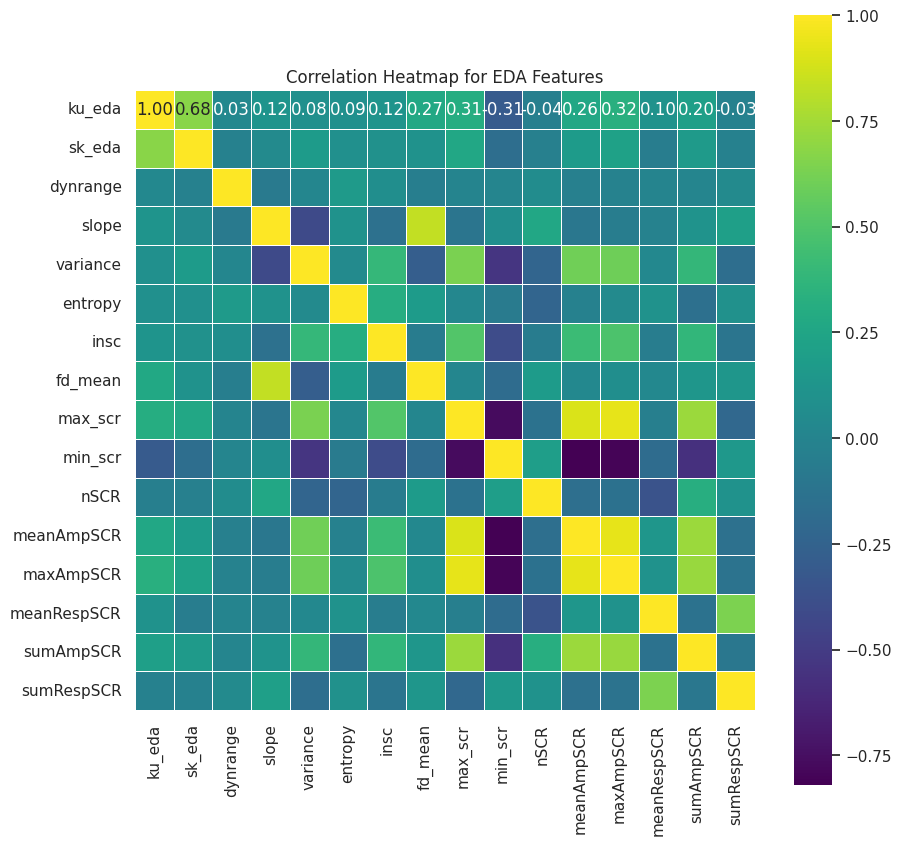

Index(['ku_eda', 'sk_eda', 'dynrange', 'slope', 'variance', 'entropy', 'insc',
       'fd_mean', 'max_scr', 'min_scr', 'nSCR', 'meanAmpSCR', 'maxAmpSCR',
       'meanRespSCR', 'sumAmpSCR', 'sumRespSCR'],
      dtype='object')


In [29]:
# Calculate the correlation matrix
correlation_matrix = eda_fet_scaled.corr()

# Identify redundant features
redundant_features = []
for feature in correlation_matrix.columns:
    correlated_features = correlation_matrix.index[
        (correlation_matrix[feature] > 0.95) & (correlation_matrix.index != feature)
    ]
    redundant_features.extend(correlated_features)

redundant_features = list(set(redundant_features))
print(redundant_features)
selected_features = [feature for feature in correlation_matrix.columns if feature not in redundant_features]

# Create a subset of the correlation matrix for selected features
reduced_correlation_matrix = correlation_matrix.loc[selected_features, selected_features]

# Create a correlation heatmap using Seaborn
plt.figure(figsize=(10, 10))  # Adjust the figure size as needed
sns.set(font_scale=1)
sns.heatmap(reduced_correlation_matrix, annot=True, cmap='viridis', cbar=True, square=True,
            fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for EDA Features')
plt.show()

print(reduced_correlation_matrix.columns)

In [30]:
eda_final_fet = eda_fet_scaled[['ku_eda', 'sk_eda', 'dynrange', 'slope', 'variance', 'entropy', 'insc',
       'fd_mean', 'max_scr', 'min_scr', 'nSCR', 'meanAmpSCR',
       'meanRespSCR', 'sumAmpSCR', 'sumRespSCR']]
eda_final_fet

,ku_eda,sk_eda,dynrange,slope,variance,entropy,insc,fd_mean,max_scr,min_scr,nSCR,meanAmpSCR,meanRespSCR,sumAmpSCR,sumRespSCR
0,0.037351,0.403454,1.0,0.574023,0.039781,0.612929,0.104090,0.601223,0.098764,0.902429,0.231624,0.071540,0.035783,0.079581,0.204550
1,0.064036,0.333815,1.0,0.520715,0.045230,0.832592,0.210263,0.553447,0.080969,0.911758,0.233642,0.104930,0.028209,0.109547,0.165493
2,0.101734,0.450899,1.0,0.569953,0.065242,0.556418,0.148348,0.609986,0.248805,0.819080,0.169611,0.248748,0.055836,0.214931,0.214020
3,0.087167,0.373848,1.0,0.491241,0.037080,0.637040,0.234430,0.530924,0.189041,0.891364,0.385675,0.207138,0.019407,0.355736,0.237451
4,0.082261,0.378626,1.0,0.506020,0.043445,0.646647,0.228999,0.601971,0.177133,0.854781,0.350990,0.233358,0.021558,0.368723,0.199579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,0.096180,0.482181,1.0,0.469287,0.024309,0.129623,0.165175,0.534357,0.139593,0.898033,0.433735,0.142565,0.014769,0.272154,0.191767
329,0.056580,0.426256,1.0,0.375119,0.049877,0.355946,0.248885,0.521406,0.163849,0.874593,0.406345,0.182482,0.031940,0.328378,0.312854
330,0.091189,0.401070,1.0,0.548603,0.051025,0.602778,0.416513,0.623501,0.219021,0.781659,0.298676,0.240286,0.011658,0.302507,0.127200
331,0.080144,0.424457,1.0,0.617114,0.135614,0.641156,0.546579,0.484104,0.593647,0.667255,0.571975,0.305515,0.009846,0.748880,0.185806


In [31]:
merged_df = pd.concat([eda_final_fet, eda_label], axis=1)
merged_df

,ku_eda,sk_eda,dynrange,slope,variance,entropy,insc,fd_mean,max_scr,min_scr,nSCR,meanAmpSCR,meanRespSCR,sumAmpSCR,sumRespSCR,Participant ID,Video ID,Gender,CMA,Video_ID_number
0,0.037351,0.403454,1.0,0.574023,0.039781,0.612929,0.104090,0.601223,0.098764,0.902429,0.231624,0.071540,0.035783,0.079581,0.204550,12,0,Male,Baseline,0
1,0.064036,0.333815,1.0,0.520715,0.045230,0.832592,0.210263,0.553447,0.080969,0.911758,0.233642,0.104930,0.028209,0.109547,0.165493,12,V1,Male,LVLA,1
2,0.101734,0.450899,1.0,0.569953,0.065242,0.556418,0.148348,0.609986,0.248805,0.819080,0.169611,0.248748,0.055836,0.214931,0.214020,12,V2,Male,LVLA,2
3,0.087167,0.373848,1.0,0.491241,0.037080,0.637040,0.234430,0.530924,0.189041,0.891364,0.385675,0.207138,0.019407,0.355736,0.237451,12,V3,Male,LVHA,3
4,0.082261,0.378626,1.0,0.506020,0.043445,0.646647,0.228999,0.601971,0.177133,0.854781,0.350990,0.233358,0.021558,0.368723,0.199579,12,V4,Male,LVHA,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,0.096180,0.482181,1.0,0.469287,0.024309,0.129623,0.165175,0.534357,0.139593,0.898033,0.433735,0.142565,0.014769,0.272154,0.191767,5,V4,Female,HVHA,4
329,0.056580,0.426256,1.0,0.375119,0.049877,0.355946,0.248885,0.521406,0.163849,0.874593,0.406345,0.182482,0.031940,0.328378,0.312854,5,V5,Female,HVLA,5
330,0.091189,0.401070,1.0,0.548603,0.051025,0.602778,0.416513,0.623501,0.219021,0.781659,0.298676,0.240286,0.011658,0.302507,0.127200,5,V6,Female,LVLA,6
331,0.080144,0.424457,1.0,0.617114,0.135614,0.641156,0.546579,0.484104,0.593647,0.667255,0.571975,0.305515,0.009846,0.748880,0.185806,5,V7,Female,LVLA,7


In [33]:
vads = pd.read_csv("Data_files/VADS.csv")
vads

,Participant ID,Playlist ID,Video ID,CMA,Valence,Arousal,Dominance,significance
0,1,1,0,Baseline,3,2,3,3
1,1,1,1,LVLA,4,3,2,3
2,1,1,2,LVLA,3,4,4,3
3,1,1,3,LVHA,3,3,3,2
4,1,1,4,LVHA,2,2,4,1
...,...,...,...,...,...,...,...,...
328,40,4,4,HVHA,5,2,4,4
329,40,4,5,HVLA,3,2,3,4
330,40,4,6,LVLA,3,2,2,4
331,40,4,7,LVLA,2,4,2,3


In [34]:
for index, row in tqdm(merged_df.iterrows()):
    matching_rows = vads[(vads['Participant ID'] == row['Participant ID']) & (vads['Video ID'] == row['Video_ID_number'])]

    if not matching_rows.empty:

        merged_df.at[index, 'Valence'] = matching_rows['Valence'].iloc[0]
        merged_df.at[index, 'Arousal'] = matching_rows['Arousal'].iloc[0]
        merged_df.at[index, 'Dominance'] = matching_rows['Dominance'].iloc[0]
        merged_df.at[index, 'significance'] = matching_rows['significance'].iloc[0]
        
merged_df

333it [00:00, 1010.80it/s]


,ku_eda,sk_eda,dynrange,slope,variance,entropy,insc,fd_mean,max_scr,min_scr,...,sumRespSCR,Participant ID,Video ID,Gender,CMA,Video_ID_number,Valence,Arousal,Dominance,significance
0,0.037351,0.403454,1.0,0.574023,0.039781,0.612929,0.104090,0.601223,0.098764,0.902429,...,0.204550,12,0,Male,Baseline,0,5.0,4.0,3.0,3.0
1,0.064036,0.333815,1.0,0.520715,0.045230,0.832592,0.210263,0.553447,0.080969,0.911758,...,0.165493,12,V1,Male,LVLA,1,4.0,4.0,4.0,2.0
2,0.101734,0.450899,1.0,0.569953,0.065242,0.556418,0.148348,0.609986,0.248805,0.819080,...,0.214020,12,V2,Male,LVLA,2,3.0,4.0,4.0,4.0
3,0.087167,0.373848,1.0,0.491241,0.037080,0.637040,0.234430,0.530924,0.189041,0.891364,...,0.237451,12,V3,Male,LVHA,3,4.0,4.0,3.0,3.0
4,0.082261,0.378626,1.0,0.506020,0.043445,0.646647,0.228999,0.601971,0.177133,0.854781,...,0.199579,12,V4,Male,LVHA,4,3.0,3.0,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,0.096180,0.482181,1.0,0.469287,0.024309,0.129623,0.165175,0.534357,0.139593,0.898033,...,0.191767,5,V4,Female,HVHA,4,4.0,1.0,4.0,3.0
329,0.056580,0.426256,1.0,0.375119,0.049877,0.355946,0.248885,0.521406,0.163849,0.874593,...,0.312854,5,V5,Female,HVLA,5,5.0,1.0,4.0,2.0
330,0.091189,0.401070,1.0,0.548603,0.051025,0.602778,0.416513,0.623501,0.219021,0.781659,...,0.127200,5,V6,Female,LVLA,6,3.0,2.0,3.0,3.0
331,0.080144,0.424457,1.0,0.617114,0.135614,0.641156,0.546579,0.484104,0.593647,0.667255,...,0.185806,5,V7,Female,LVLA,7,3.0,2.0,3.0,3.0


In [ ]:
eda_data_with_labels = label_prep(merged_df)
eda_data_with_labels.to_csv("../Data_files/EDA_labels.csv")
eda_data_with_labels

In [ ]:
# Define the bins and labels for categorization
bins = [1, 3, 5]  # Define the bin edges
labels = [0, 1]   # Define the corresponding labels (0 (Low) for 1-3:, 1 (High) for 4-5)

# Use the cut function to categorize the 'arousal' column
merged_df['arousal_category'] = pd.cut(merged_df['Arousal'], bins=bins, labels=labels, include_lowest=True)
merged_df['valence_category'] = pd.cut(merged_df['Valence'], bins=bins, labels=labels, include_lowest=True)

# Convert the 'category' column to integer type if needed
merged_df['arousal_category'] = merged_df['arousal_category'].astype(int)
merged_df['valence_category'] = merged_df['valence_category'].astype(int)
merged_df

In [ ]:
# merged_df.to_csv("eda_stat_fet",index=False)

In [35]:
def plot_tsne(eda_final_fet, valence_col, arousal_col, valence, arousal):

    # Apply t-SNE to reduce dimensions
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(eda_final_fet)

    # Create a DataFrame with t-SNE results
    tsne_df = pd.DataFrame(tsne_results, columns=['t-SNE1', 't-SNE2'])
    tsne_df['Label'] = valence_col

    # Plotting the t-SNE results with colors based on labels
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(tsne_df['t-SNE1'], tsne_df['t-SNE2'], c=tsne_df['Label'], cmap='viridis')
    plt.title(f't-SNE Plot of Features Colored by {valence}')
    plt.xlabel('t-SNE1')
    plt.ylabel('t-SNE2')
    plt.colorbar(scatter, label='Label')
    plt.show()

    # # Apply t-SNE to reduce dimensions
    # tsne = TSNE(n_components=2, random_state=42)
    # tsne_results = tsne.fit_transform(eda_final_fet)

    # # Create a DataFrame with t-SNE results
    # tsne_df = pd.DataFrame(tsne_results, columns=['t-SNE1', 't-SNE2'])
    tsne_df['Label'] = arousal_col

    # Plotting the t-SNE results with colors based on labels
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(tsne_df['t-SNE1'], tsne_df['t-SNE2'], c=tsne_df['Label'], cmap='viridis')
    plt.title(f't-SNE Plot of Features Colored by {arousal}')
    plt.xlabel('t-SNE1')
    plt.ylabel('t-SNE2')
    plt.colorbar(scatter, label='Label')
    plt.show()

plot_tsne(eda_final_fet, merged_df['valence_category'], merged_df['arousal_category'], 'valence', 'arousal')

KeyError: 'valence_category'

In [ ]:
mapping = {
    'Baseline': 1,
    'LVLA': 1,
    'LVHA': 1,
    'HVHA': 0,
    'HVLA': 0  # Baseline and HVLA mapped to 0
}

# Apply the mapping to the 'CMA' column
merged_df['CMA_numeric'] = merged_df['CMA'].map(mapping)
# autofet_df

merged_df['stress'] = merged_df['CMA'].apply(lambda x: 0 if x in ['Baseline', 'HVLA'] else 1)
merged_df

In [ ]:
plot_tsne(eda_final_fet, merged_df['CMA_numeric'], merged_df['stress'], 'CMA', 'stress')

In [ ]:
merged_df.to_csv("../Data_files/EDA_FINAL_FET.csv", index=False)

In [ ]:
ghq_p =pd.read_csv("../Data_files/GHQ-Personality_category_sheet.csv")
ghq_p

In [ ]:
for index, row in tqdm(merged_df.iterrows()):
    matching_rows = ghq_p[(ghq_p['Participant ID'] == row['Participant ID'])]

    if not matching_rows.empty:

        merged_df.at[index, 'GHQ Score'] = matching_rows['GHQ Score'].iloc[0]
        merged_df.at[index, 'GHQ Category'] = matching_rows['GHQ Category'].iloc[0]
        
merged_df

In [ ]:
merged_df['ghq_category'] = merged_df['GHQ Category'].apply(lambda x: 0 if x in ['Distressed'] else 1)
merged_df

In [ ]:
merged_df['Gender_category'] = merged_df['Gender'].apply(lambda x : 0 if x in ['Male'] else 1)
merged_df.columns

In [ ]:
plot_tsne(eda_final_fet, merged_df['ghq_category'], merged_df['Gender_category'], 'ghq_category', 'Gender_category')